# Random Forest + SHAP Analysis
Optimized for performance: shallow RF, small background sample for SHAP.

In [ ]:
# Install dependencies if needed
# !pip install shap scikit-learn pandas numpy matplotlib

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import sys
sys.path.append('/mnt/cbib/LNClassifier/paper/workflow/')
from utils.features import filter_feature_columns, remove_constant_features
from utils.entropy import load_dataset
from utils.parsing import simple_load_ids

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load Data

In [ ]:
dataset = load_dataset('gencode.v47.common.cdhit.cv')
features_df = dataset['features']
labels_df = dataset['labels']

Extracted 8 probability columns.
Inverting noncoding probabilities...
  - Inverting column: Noncoding_prob_ss_lncDC


In [ ]:
features_df

,fold,coding_score_rnasamba,label_rnasamba,temp_id,kmerScore_1mer_feelnc,kmerScore_2mer_feelnc,kmerScore_3mer_feelnc,kmerScore_6mer_feelnc,kmerScore_9mer_feelnc,kmerScore_12mer_feelnc,...,SS.pct.dist_lncfinder,SS.Dist.Ratio_lncfinder,MFE_lncfinder,UP.PCT_lncfinder,label_ss_lncfinder,Pred_lncfinder,Coding.Potential_lncfinder,label_lncfinder,metadata,biotype
seq_ID,,,,,,,,,,,,,,,,,,,,,
ENST00000000412.8,fold1,0.99411,coding,ENST00000000412.8,0.500532,0.500517,0.521942,0.547063,0.550243,0.484597,...,-0.043689,0.948800,-766.2,0.109024,coding,Coding,0.964479,coding,ENST00000000412.8|ENSG00000003056.8|OTTHUMG000...,protein_coding
ENST00000002596.6,fold1,0.98732,coding,ENST00000002596.6,0.506236,0.516955,0.552951,0.614614,0.638448,0.500128,...,-0.012413,0.846316,-2201.2,0.110211,coding,Coding,0.992227,coding,ENST00000002596.6|ENSG00000002587.10|OTTHUMG00...,protein_coding
ENST00000002829.8,fold1,0.99930,coding,ENST00000002829.8,0.506685,0.516865,0.550626,0.604411,0.633491,0.513626,...,-0.031147,0.842343,-1583.8,0.118414,coding,Coding,0.997396,coding,ENST00000002829.8|ENSG00000001617.12|OTTHUMG00...,protein_coding
ENST00000005260.9,fold1,0.99168,coding,ENST00000005260.9,0.502833,0.508791,0.530998,0.563220,0.573943,0.468130,...,-0.018515,0.784500,-1231.3,0.116905,coding,Coding,0.959746,coding,ENST00000005260.9|ENSG00000006453.14|OTTHUMG00...,protein_coding
ENST00000005995.8,fold1,0.97452,coding,ENST00000005995.8,0.505395,0.513231,0.533184,0.566367,0.577786,0.493292,...,-0.110237,0.883350,-440.1,0.122936,coding,Coding,0.908101,coding,ENST00000005995.8|ENSG00000007038.11|OTTHUMG00...,protein_coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000715715.1,fold5,0.04422,noncoding,ENST00000715715.1,0.498402,0.497692,0.493839,0.487290,0.453654,0.375686,...,-0.072700,0.941463,-453.3,0.110757,noncoding,NonCoding,0.030319,noncoding,ENST00000715715.1|ENSG00000242553.3|OTTHUMG000...,lncRNA
ENST00000715718.1,fold5,0.00632,noncoding,ENST00000715718.1,0.502086,0.505426,0.503883,0.495754,0.449565,0.332127,...,-0.126897,1.014876,-315.9,0.111111,noncoding,NonCoding,0.099544,noncoding,ENST00000715718.1|ENSG00000229443.3|OTTHUMG000...,lncRNA
ENST00000715720.1,fold5,0.24308,noncoding,ENST00000715720.1,0.508883,0.522687,0.527667,0.548416,0.509664,0.312139,...,-0.020005,0.848949,-1340.7,0.111831,noncoding,NonCoding,0.069115,noncoding,ENST00000715720.1|ENSG00000278156.4|OTTHUMG000...,lncRNA


In [ ]:
# Per fold, get IDs of transcripts in train and test set
for i in range(1, 6):
    train_pc_fasta = f"/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/datasets/fold{i}/train_pc.fa"
    train_lnc_fasta = f"/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/datasets/fold{i}/train_lnc.fa"
    test_pc_fasta = f"/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/datasets/fold{i}/test_pc.fa"
    test_lnc_fasta = f"/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/datasets/fold{i}/test_lnc.fa"
    
    # Extract transcript IDs from FASTA files
    train_pc_ids = set(simple_load_ids(train_pc_fasta, simple=True))
    train_lnc_ids = set(simple_load_ids(train_lnc_fasta, simple=True))
    test_pc_ids = set(simple_load_ids(test_pc_fasta, simple=True))
    test_lnc_ids = set(simple_load_ids(test_lnc_fasta, simple=True))
    

    # Only keep transcripts that are in the features dataset
    train_pc_ids = train_pc_ids.intersection(features_df.index)
    train_lnc_ids = train_lnc_ids.intersection(features_df.index)
    test_pc_ids = test_pc_ids.intersection(features_df.index)
    test_lnc_ids = test_lnc_ids.intersection(features_df.index)

    print(f"Fold {i}:")
    print(f"  Train PC: {len(train_pc_ids)} transcripts")
    print(f"  Train lnc: {len(train_lnc_ids)} transcripts")
    print(f"  Test PC: {len(test_pc_ids)} transcripts")
    print(f"  Test lnc: {len(test_lnc_ids)} transcripts")


Fold 1:
  Train PC: 36256 transcripts
  Train lnc: 36218 transcripts
  Test PC: 13288 transcripts
  Test lnc: 9058 transcripts
Fold 2:
  Train PC: 36267 transcripts
  Train lnc: 36227 transcripts
  Test PC: 13272 transcripts
  Test lnc: 9049 transcripts
Fold 3:
  Train PC: 36271 transcripts
  Train lnc: 36223 transcripts
  Test PC: 13281 transcripts
  Test lnc: 9053 transcripts
Fold 4:
  Train PC: 36284 transcripts
  Train lnc: 36209 transcripts
  Test PC: 13265 transcripts
  Test lnc: 9067 transcripts
Fold 5:
  Train PC: 36265 transcripts
  Train lnc: 36227 transcripts
  Test PC: 13270 transcripts
  Test lnc: 9049 transcripts


### 1.2 Load TE and NBD data

In [ ]:
# Load TE and NBD features

te_feats = pd.read_csv('/mnt/cbib/LNClassifier/paper/te_pipeline/results/te_analysis_flexible/features/all_transcripts_te_features.csv')
nbd_feats = pd.read_csv('/mnt/cbib/LNClassifier/paper/nonb-pipeline/results/gencode.v47/extended_analysis/features_nonb_features.csv')

# Preprocess TE and NBD features
te_feats = te_feats.set_index('transcript_id')
te_feats = te_feats.select_dtypes(include='number').fillna(0)
te_feats = remove_constant_features(te_feats)

nbd_feats = nbd_feats.set_index('transcript_id')
nbd_feats = nbd_feats.select_dtypes(include='number').fillna(0)
nbd_feats = remove_constant_features(nbd_feats)


Dataset: Removing 9 constant features
  Constant features: ['te_ervk_count', 'te_ervl_count', 'te_ervl-malr_count', 'te_erv1_count', 'pseudo_unique_families', 'te_ervk_count_per_kb', 'te_ervl_count_per_kb', 'te_ervl-malr_count_per_kb', 'te_erv1_count_per_kb']
Dataset: No constant features were removed


## 1.Bis: Load fold data only

In [ ]:
fold_features = pd.read_csv('/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/fold1/tables/fold1_full_table.tsv', sep='\t')
fold_binary = pd.read_csv('/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/fold1/tables/fold1_binary_class_table.tsv', sep='\t')
fold_class = pd.read_csv('/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/testing/fold1/tables/fold1_simple_class_table.tsv', sep='\t')

In [ ]:
fold_features = fold_features.set_index('seq_ID')
fold_binary = fold_binary.set_index('seq_ID')
fold_class = fold_class.set_index('seq_ID')

In [ ]:
features_to_keep = filter_feature_columns(fold_features)
fold_features = fold_features[features_to_keep]
fold_features = remove_constant_features(fold_features)
fold_features

Identified length columns to exclude: ['Transcript_length_lncDC', 'length_plncpro'] (keeping RNA_size_feelnc for reference)
Total number of columns in features table: 171
Number of kept feature columns: 128
Feature columns: ['kmerScore_1mer_feelnc', 'kmerScore_2mer_feelnc', 'kmerScore_3mer_feelnc', 'kmerScore_6mer_feelnc', 'kmerScore_9mer_feelnc', 'kmerScore_12mer_feelnc', 'ORF_cover_feelnc', 'RNA_size_feelnc', 'ORF_l_cpat', 'Fickett_l_cpat', 'Hexamer_l_cpat', 'ORF_coverage_l_cpat', 'GC_content_lncDC', 'Fickett_score_lncDC', 'ORF_T0_length_lncDC', 'ORF_T1_length_lncDC', 'ORF_T2_length_lncDC', 'ORF_T0_coverage_lncDC', 'ORF_T1_coverage_lncDC', 'ORF_T3_coverage_lncDC', 'Hexamer_score_ORF_T0_lncDC', 'Hexamer_score_ORF_T1_lncDC', 'Hexamer_score_ORF_T2_lncDC', 'Hexamer_score_ORF_T3_lncDC', 'RCB_T0_lncDC', 'RCB_T1_lncDC', 'ORF_T0_PI_lncDC', 'ORF_T0_MW_lncDC', 'ORF_T0_aromaticity_lncDC', 'ORF_T0_instability_lncDC', 'ORF_T1_MW_lncDC', 'ORF_T1_instability_lncDC', 'ORF_T2_MW_lncDC', 'ORF_T3_MW_ln

,kmerScore_1mer_feelnc,kmerScore_2mer_feelnc,kmerScore_3mer_feelnc,kmerScore_6mer_feelnc,kmerScore_9mer_feelnc,kmerScore_12mer_feelnc,ORF_cover_feelnc,RNA_size_feelnc,ORF_l_cpat,Fickett_l_cpat,...,Signal.Q2_lncfinder,Signal.Max_lncfinder,Dot_lnc.dist_lncfinder,Dot_pct.dist_lncfinder,Dot_Dist.Ratio_lncfinder,SS.lnc.dist_lncfinder,SS.pct.dist_lncfinder,SS.Dist.Ratio_lncfinder,MFE_lncfinder,UP.PCT_lncfinder
seq_ID,,,,,,,,,,,,,,,,,,,,,
ENST00000000412.8,0.500532,0.500517,0.521942,0.547063,0.550243,0.484597,0.340408,2450.0,834.0,0.9882,...,3.612083,9.503012,-0.035259,-0.038387,0.918522,-0.041452,-0.043689,0.948800,-766.2,0.109024
ENST00000002596.6,0.506236,0.516955,0.552951,0.614614,0.638448,0.500128,0.129050,7160.0,924.0,1.3522,...,9.930891,34.428530,-0.003786,-0.006761,0.560014,-0.010505,-0.012413,0.846316,-2201.2,0.110211
ENST00000002829.8,0.506685,0.516865,0.550626,0.604411,0.633491,0.513626,0.653729,3607.0,2358.0,1.1447,...,5.809128,14.438914,-0.027893,-0.036709,0.759835,-0.026237,-0.031147,0.842343,-1583.8,0.118414
ENST00000005260.9,0.502833,0.508791,0.530998,0.563220,0.573943,0.468130,0.486420,3645.0,1536.0,0.9867,...,5.441633,20.423523,-0.008949,-0.015182,0.589437,-0.014525,-0.018515,0.784500,-1231.3,0.116905
ENST00000005995.8,0.505395,0.513231,0.533184,0.566367,0.577786,0.493292,0.893676,1091.0,945.0,0.9491,...,1.691524,5.218731,-0.108187,-0.132658,0.815534,-0.097378,-0.110237,0.883350,-440.1,0.122936
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000715712.2,0.503924,0.510138,0.521858,0.559903,0.589390,0.411925,0.156457,1208.0,138.0,0.6773,...,1.508426,11.932073,-0.084880,-0.090663,0.936218,-0.099733,-0.102186,0.976000,-320.2,0.111019
ENST00000715713.1,0.503530,0.507506,0.501012,0.495705,0.467876,0.393253,0.385529,926.0,357.0,0.6297,...,1.306351,3.033553,-0.128831,-0.138194,0.932251,-0.113073,-0.119506,0.946165,-270.9,0.128649
ENST00000715716.1,0.502773,0.509304,0.494120,0.511941,0.522227,0.431212,0.875776,161.0,117.0,0.9291,...,0.261088,0.630419,-2.157304,-2.181138,0.989073,-1.579562,-1.597298,0.988897,-50.6,0.093750


In [ ]:
# Transform fold features as numeric and fill nan with 0
for col in fold_features.columns:
    fold_features[col] = pd.to_numeric(fold_features[col], errors='coerce').fillna(0)
real = fold_binary["real"].astype(int)

In [ ]:

all_fold_features = fold_features.join(te_feats, how='left').join(nbd_feats, how='left', rsuffix='_nbd').fillna(0)
all_fold_features.drop(columns=[col for col in fold_features.columns if col.endswith('_nbd')], inplace=True)

In [ ]:
# Ensure indices match between features and labels
all_fold_features = all_fold_features.loc[real.index]

In [ ]:
print(f"Total number of features after adding TE and NBD features: {all_fold_features.shape[1]}")
print(f"Number of transcripts: {all_fold_features.shape[0]}")


Total number of features after adding TE and NBD features: 446
Number of transcripts: 22346


In [ ]:
X = all_fold_features
y = real

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [ ]:
# Using breast cancer dataset as example — swap in your own data here
# data = load_breast_cancer()
# X = pd.DataFrame(data.data, columns=data.feature_names)
# y = pd.Series(data.target, name="target")

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=RANDOM_STATE
# )

# print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
# X.head()

## 2. Train a Lightweight Random Forest
Key performance levers:
- `max_depth` — shallow trees = faster SHAP
- `max_leaf_nodes` — caps tree complexity
- `n_estimators` — fewer trees = faster
- `max_features` — subsampling features per split

In [ ]:
# rf = RandomForestClassifier(
#     n_estimators=500,       # fewer trees → faster SHAP
#     max_depth=4,           # shallow trees → faster SHAP
#     max_leaf_nodes=16,     # hard cap on leaves per tree
#     max_features="sqrt",   # standard good default
#     n_jobs=-1,             # use all CPU cores
#     random_state=RANDOM_STATE
# )

rf = RandomForestClassifier(
    n_jobs=-1,             # use all CPU cores
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))#, target_names=data.target_names))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1813
           1       0.94      0.93      0.94      2657

    accuracy                           0.93      4470
   macro avg       0.92      0.93      0.93      4470
weighted avg       0.93      0.93      0.93      4470



## 3. Compute SHAP Values
Using `TreeExplainer` (fast, exact for tree models) with a small background sample.

In [ ]:
# Small background sample drastically reduces SHAP computation time
BACKGROUND_SAMPLE_SIZE = 500  # increase for more accurate baseline, decrease to go faster

background = X_train.sample(n=BACKGROUND_SAMPLE_SIZE, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(
    rf,
    data=background,          # background dataset for expected value
    feature_perturbation="interventional"  # more accurate with background data
)

print("SHAP explainer created.")
print(f"Expected value (base rate): {explainer.expected_value}")

SHAP explainer created.
Expected value (base rate): [0.4534 0.5466]


## 4. Compute Shapley Values for Items of Interest

In [ ]:
# ---------------------------------------------------------------
# DEFINE YOUR ITEMS HERE
# Option A: pick rows from the test set by index
item_indices = list(range(len(X_test)))  # ← change these to your items of interest
items_to_explain = X_test.iloc[item_indices].copy()

# Option B: define custom items manually (uncomment and edit)
# items_to_explain = pd.DataFrame([
#     {"feature_1": 1.5, "feature_2": 0.3, ...},  # item 1
#     {"feature_1": 2.1, "feature_2": 1.7, ...},  # item 2
# ])
# ---------------------------------------------------------------

print(f"Computing SHAP values for {len(items_to_explain)} items...")
shap_values = explainer.shap_values(items_to_explain)

# For binary classification, shap_values is a list [class_0, class_1]
# We'll use class 1 (positive class)
if isinstance(shap_values, list):
    # Old SHAP format: list of arrays, one per class
    sv = shap_values[1]
    base_value = explainer.expected_value[1]
elif shap_values.ndim == 3:
    # New SHAP format: single 3D array (n_samples, n_features, n_classes)
    sv = shap_values[:, :, 1]
    base_value = explainer.expected_value[1]
else:
    # Regression or single-output
    sv = shap_values
    base_value = explainer.expected_value

shap_df = pd.DataFrame(sv, columns=X_train.columns, index=items_to_explain.index)
print("Done!")
shap_df

Computing SHAP values for 4470 items...


100%|===================| 8938/8940 [05:32<00:00]        

Done!


,kmerScore_1mer_feelnc,kmerScore_2mer_feelnc,kmerScore_3mer_feelnc,kmerScore_6mer_feelnc,kmerScore_9mer_feelnc,kmerScore_12mer_feelnc,ORF_cover_feelnc,RNA_size_feelnc,ORF_l_cpat,Fickett_l_cpat,...,all_nonb_gaps_mean,all_nonb_gaps_median,all_nonb_gaps_max,all_nonb_gaps_min,any_nonb_present,motif_types_present,total_nonb_count,total_nonb_coverage,total_nonb_coverage_pct,motif_diversity
seq_ID,,,,,,,,,,,,,,,,,,,,,
ENST00000546699.1,0.000887,0.000352,-0.005241,-0.008804,-0.026976,-0.049105,-0.004460,0.000748,-0.021917,-0.005085,...,-0.000189,0.000453,0.000053,0.000079,0.0,-0.000051,-0.000630,-0.000816,-0.000236,-0.000067
ENST00000665140.1,0.001601,0.001155,-0.007315,-0.017354,-0.030320,-0.069310,-0.021335,-0.000785,-0.008921,-0.004035,...,0.000022,0.000245,0.000361,0.000053,0.0,-0.000014,0.000581,0.000809,0.000057,-0.000104
ENST00000396836.6,0.001831,0.000822,0.003400,0.007450,0.006350,0.024236,0.013477,0.001783,0.037490,-0.000564,...,0.000008,-0.001486,0.000489,-0.000069,0.0,0.000017,0.002610,0.001848,0.000735,-0.001555
ENST00000591811.1,-0.001397,-0.001415,0.012376,0.006150,0.006702,0.035972,0.020867,0.003758,-0.015739,-0.011504,...,-0.000446,-0.000305,0.000077,0.000499,0.0,-0.000048,0.001779,0.000161,-0.000147,0.000069
ENST00000520151.5,0.002863,0.000759,-0.000765,0.000619,-0.006516,0.025188,0.016594,0.004875,0.000956,0.003401,...,-0.000094,-0.000578,0.000589,0.000088,0.0,0.000090,0.000773,0.001993,0.000068,0.000278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000525309.1,0.002709,0.002040,-0.008889,-0.015776,-0.035422,-0.040346,-0.009495,-0.001354,-0.022016,-0.007045,...,-0.000121,0.000113,0.000215,0.000038,0.0,0.000044,0.001042,0.000825,0.000010,0.000237
ENST00000652096.1,0.000562,-0.000090,0.005337,0.013079,0.022993,0.035990,0.011432,-0.000051,0.014846,0.005153,...,0.000237,0.001156,0.000326,-0.003768,0.0,-0.000005,0.001415,0.001005,0.000615,0.000123
ENST00000690647.2,0.000745,0.000036,-0.004421,-0.007891,-0.022780,-0.002451,-0.004994,-0.001037,-0.020792,-0.005461,...,-0.000195,0.000387,-0.000266,0.000128,0.0,-0.000036,-0.002160,-0.002223,-0.000916,0.000030


## 5. Visualize Results

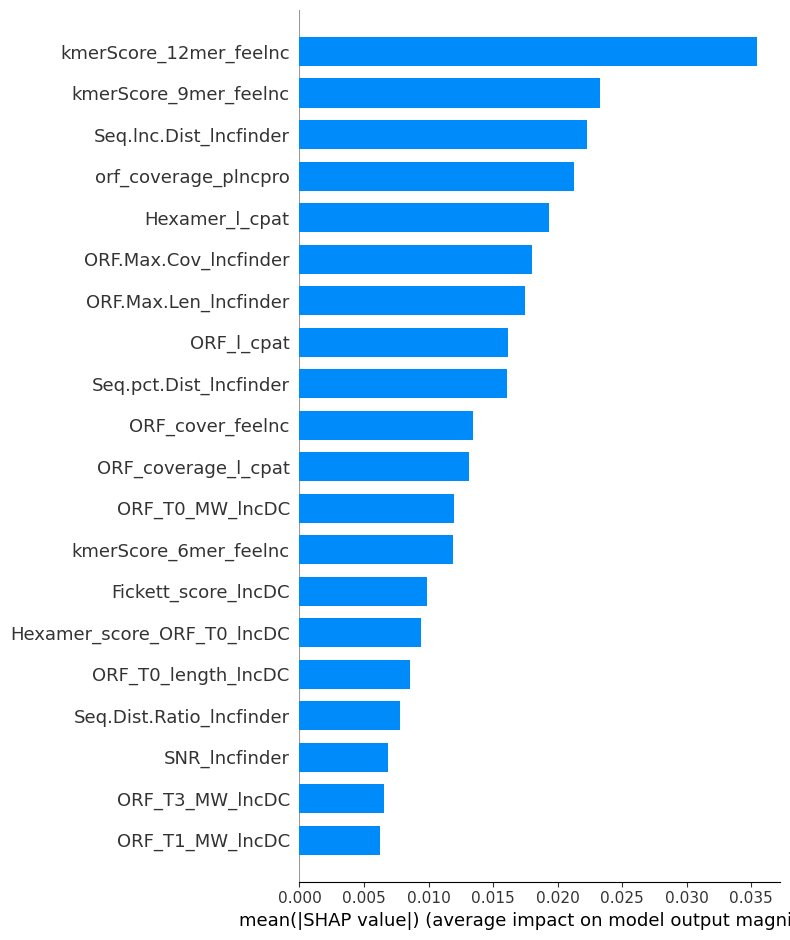

In [ ]:
# --- Global: Summary plot (all items) ---
shap.summary_plot(sv, items_to_explain, plot_type="bar", show=True)

```
low_pc = ['ENST00000265171', 'ENST00000522362', 'ENST00000293599', 'ENST00000704677', 'ENST00000342193', 'ENST00000554192', 'ENST00000674628', 'ENST00000713679']
low_pc = ['EGF', 'PNMA2', 'AQP5', 'UPF1', 'COBLL1', 'AKT1', 'DICER1', 'BRCA2']
low_lnc = ['ENST00000434839', 'ENST00000710870']
low_lnc = ['XIST', 'MALAT1']
high_pc = ['ENST00000361567', 'ENST00000503087', 'ENST00000608796', 'ENST00000581411', 'ENST00000651610']
high_pc = ['MT-ND5', 'TGFBI', 'SWI5', 'TP53I13', 'AQP1']
high_lnc = ['ENST00000524131', 'ENST00000554894']
high_lnc = ['MEG3', 'CHASERR']
```

In [ ]:
low_pc = ['ENST00000265171', 'ENST00000522362', 'ENST00000293599', 'ENST00000704677', 'ENST00000342193', 'ENST00000554192', 'ENST00000674628', 'ENST00000713679']
low_lnc = ['ENST00000434839', 'ENST00000710870']
high_pc = ['ENST00000361567', 'ENST00000503087', 'ENST00000608796', 'ENST00000581411', 'ENST00000651610']
high_lnc = ['ENST00000524131', 'ENST00000554894']

for lst in [low_pc, low_lnc, high_pc, high_lnc]:
    dirty_shap = shap_df.copy()
    dirty_shap.index = dirty_shap.index.str.split(".").str[0]  # remove version numbers for matching
    lst = [x for x in lst if x in dirty_shap.index]  # filter to only those present in the SHAP results
    print(f"SHAP values for {lst}:")
    display(dirty_shap.loc[lst])

SHAP values for []:


,kmerScore_1mer_feelnc,kmerScore_2mer_feelnc,kmerScore_3mer_feelnc,kmerScore_6mer_feelnc,kmerScore_9mer_feelnc,kmerScore_12mer_feelnc,ORF_cover_feelnc,RNA_size_feelnc,ORF_l_cpat,Fickett_l_cpat,...,all_nonb_gaps_mean,all_nonb_gaps_median,all_nonb_gaps_max,all_nonb_gaps_min,any_nonb_present,motif_types_present,total_nonb_count,total_nonb_coverage,total_nonb_coverage_pct,motif_diversity
seq_ID,,,,,,,,,,,,,,,,,,,,,


SHAP values for []:


,kmerScore_1mer_feelnc,kmerScore_2mer_feelnc,kmerScore_3mer_feelnc,kmerScore_6mer_feelnc,kmerScore_9mer_feelnc,kmerScore_12mer_feelnc,ORF_cover_feelnc,RNA_size_feelnc,ORF_l_cpat,Fickett_l_cpat,...,all_nonb_gaps_mean,all_nonb_gaps_median,all_nonb_gaps_max,all_nonb_gaps_min,any_nonb_present,motif_types_present,total_nonb_count,total_nonb_coverage,total_nonb_coverage_pct,motif_diversity
seq_ID,,,,,,,,,,,,,,,,,,,,,


SHAP values for ['ENST00000361567']:


,kmerScore_1mer_feelnc,kmerScore_2mer_feelnc,kmerScore_3mer_feelnc,kmerScore_6mer_feelnc,kmerScore_9mer_feelnc,kmerScore_12mer_feelnc,ORF_cover_feelnc,RNA_size_feelnc,ORF_l_cpat,Fickett_l_cpat,...,all_nonb_gaps_mean,all_nonb_gaps_median,all_nonb_gaps_max,all_nonb_gaps_min,any_nonb_present,motif_types_present,total_nonb_count,total_nonb_coverage,total_nonb_coverage_pct,motif_diversity
seq_ID,,,,,,,,,,,,,,,,,,,,,
ENST00000361567,0.000696,0.002001,-0.002568,-0.001342,0.003572,0.00387,-0.026179,-0.001755,-0.018531,0.004608,...,0.001311,0.000691,0.000342,-0.00166,0.0,0.00033,-0.007069,-0.002812,-0.002363,0.000512


SHAP values for []:


,kmerScore_1mer_feelnc,kmerScore_2mer_feelnc,kmerScore_3mer_feelnc,kmerScore_6mer_feelnc,kmerScore_9mer_feelnc,kmerScore_12mer_feelnc,ORF_cover_feelnc,RNA_size_feelnc,ORF_l_cpat,Fickett_l_cpat,...,all_nonb_gaps_mean,all_nonb_gaps_median,all_nonb_gaps_max,all_nonb_gaps_min,any_nonb_present,motif_types_present,total_nonb_count,total_nonb_coverage,total_nonb_coverage_pct,motif_diversity
seq_ID,,,,,,,,,,,,,,,,,,,,,



--- Item 0 (index=ENST00000546699.1) ---


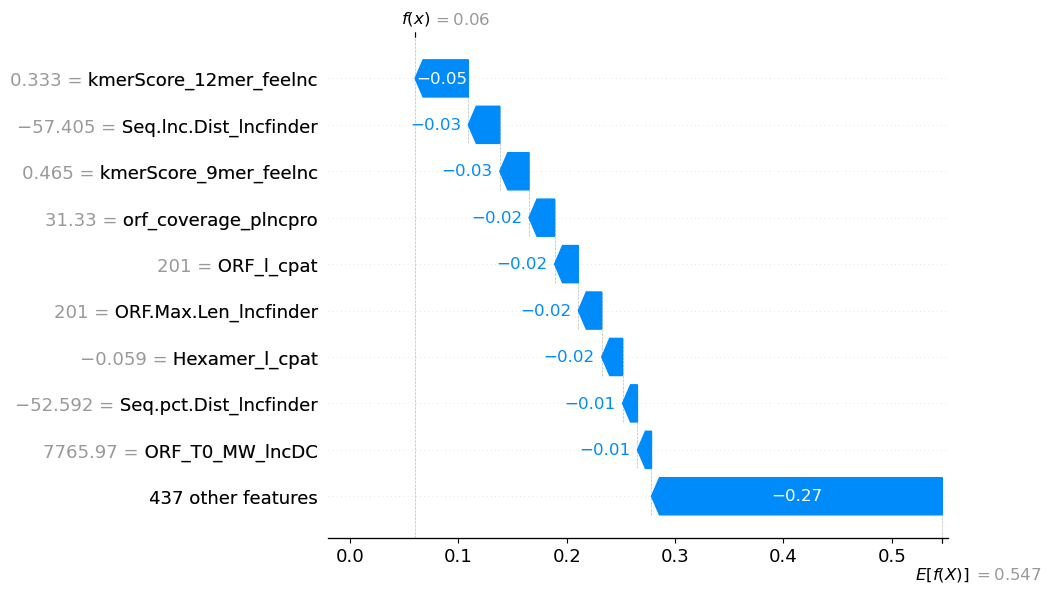


--- Item 1 (index=ENST00000665140.1) ---


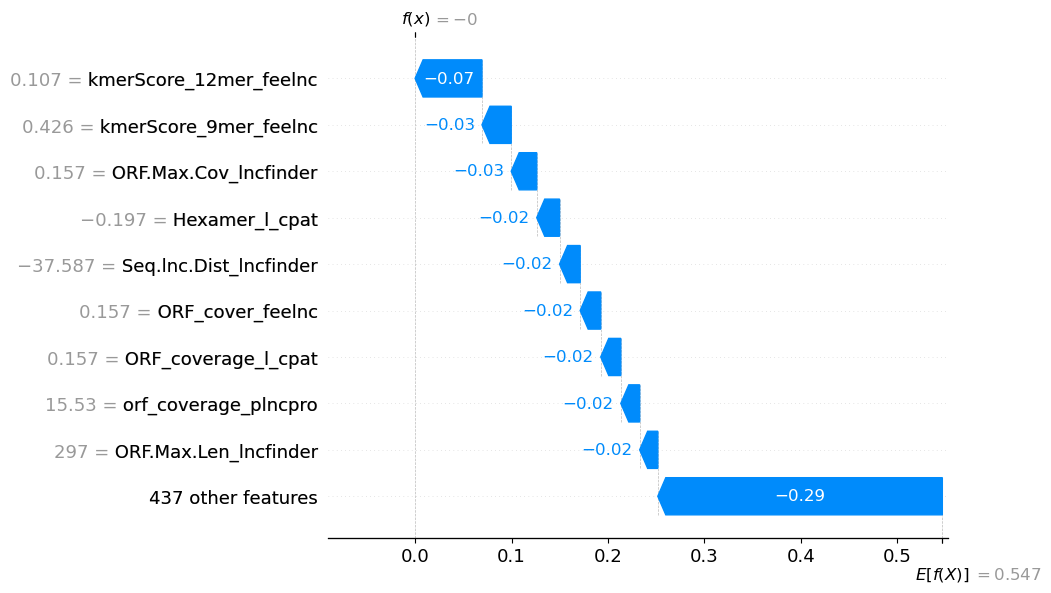


--- Item 2 (index=ENST00000396836.6) ---


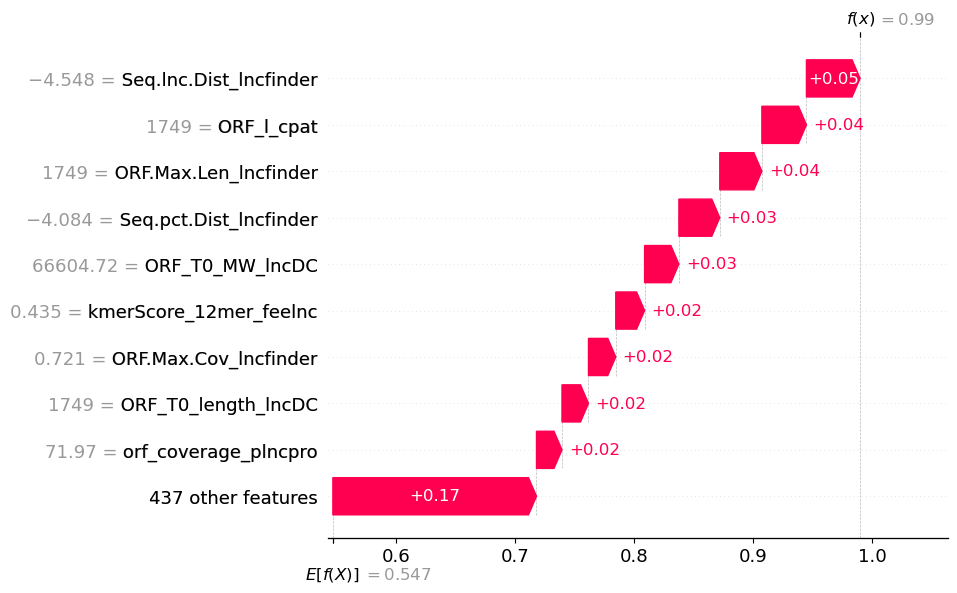


--- Item 3 (index=ENST00000591811.1) ---


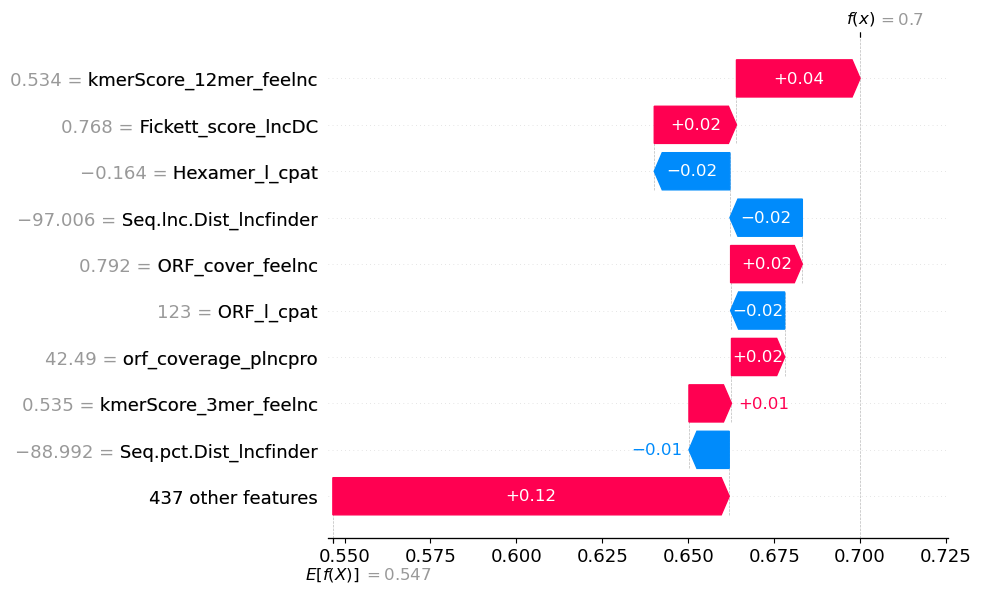


--- Item 4 (index=ENST00000520151.5) ---


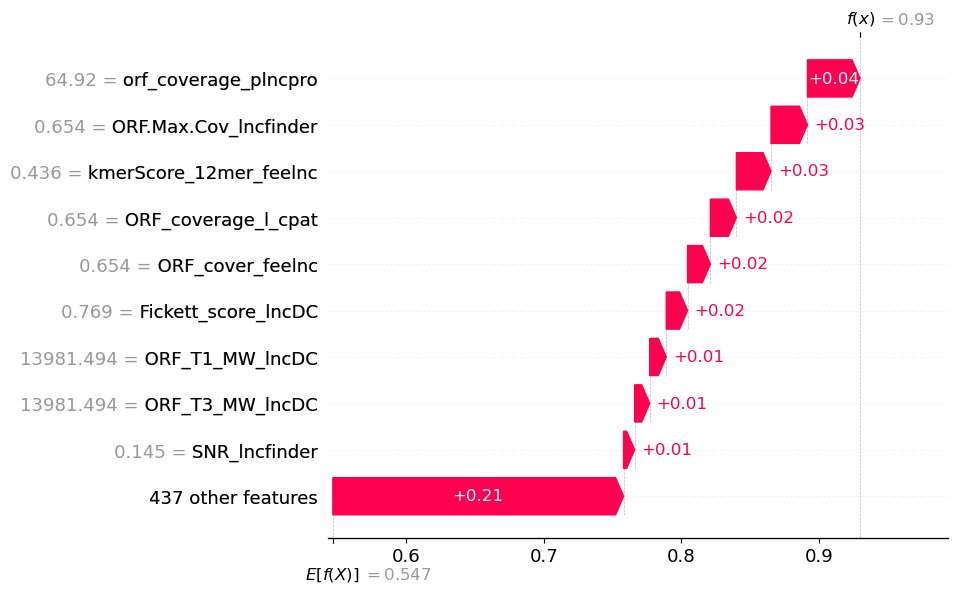

In [ ]:
# --- Per-item: Waterfall plot for each item ---
for i, (idx, row) in enumerate(items_to_explain[:5].iterrows()):
    print(f"\n--- Item {i} (index={idx}) ---")
    explanation = shap.Explanation(
        values=sv[i],
        base_values=base_value,
        data=row.values,
        feature_names=X_train.columns.tolist()
    )
    shap.plots.waterfall(explanation, show=True)

In [ ]:
# --- Top features per item (tabular summary) ---
print("Top 5 most impactful features per item:\n")
for i, (idx, row) in enumerate(shap_df.iterrows()):
    top5 = row.abs().nlargest(5)
    print(f"Item {i} (index={idx}):")
    for feat, val in top5.items():
        direction = "+" if row[feat] > 0 else "-"
        print(f"  {direction} {feat:<35} SHAP={row[feat]:+.4f}")
    print()

Top 5 most impactful features per item:

Item 0 (index=ENST00000546699.1):
  - kmerScore_12mer_feelnc              SHAP=-0.0491
  - Seq.lnc.Dist_lncfinder              SHAP=-0.0291
  - kmerScore_9mer_feelnc               SHAP=-0.0270
  - orf_coverage_plncpro                SHAP=-0.0236
  - ORF_l_cpat                          SHAP=-0.0219

Item 1 (index=ENST00000665140.1):
  - kmerScore_12mer_feelnc              SHAP=-0.0693
  - kmerScore_9mer_feelnc               SHAP=-0.0303
  - ORF.Max.Cov_lncfinder               SHAP=-0.0265
  - Hexamer_l_cpat                      SHAP=-0.0237
  - Seq.lnc.Dist_lncfinder              SHAP=-0.0214

Item 2 (index=ENST00000396836.6):
  + Seq.lnc.Dist_lncfinder              SHAP=+0.0451
  + ORF_l_cpat                          SHAP=+0.0375
  + ORF.Max.Len_lncfinder               SHAP=+0.0354
  + Seq.pct.Dist_lncfinder              SHAP=+0.0344
  + ORF_T0_MW_lncDC                     SHAP=+0.0288

Item 3 (index=ENST00000591811.1):
  + kmerScore_12mer_feeln